# モンテカルロシミュレーションの数理とPython実装
## 幾何ブラウン運動で株価の未来を確率的に予測する

このノートブックは、Zenn記事「モンテカルロシミュレーションの数理とPython実装」の実装コードです。

### データ
- 銘柄: AAPL（メイン）, MSFT, AMZN, JPM, JNJ（ポートフォリオ応用）
- 期間: 2000-01-01 ~ 2025-12-31

## 0. 環境セットアップ

In [ ]:
!pip install yfinance -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

## 1. モンテカルロシミュレーションとは

### 図1: 円周率のモンテカルロ推定

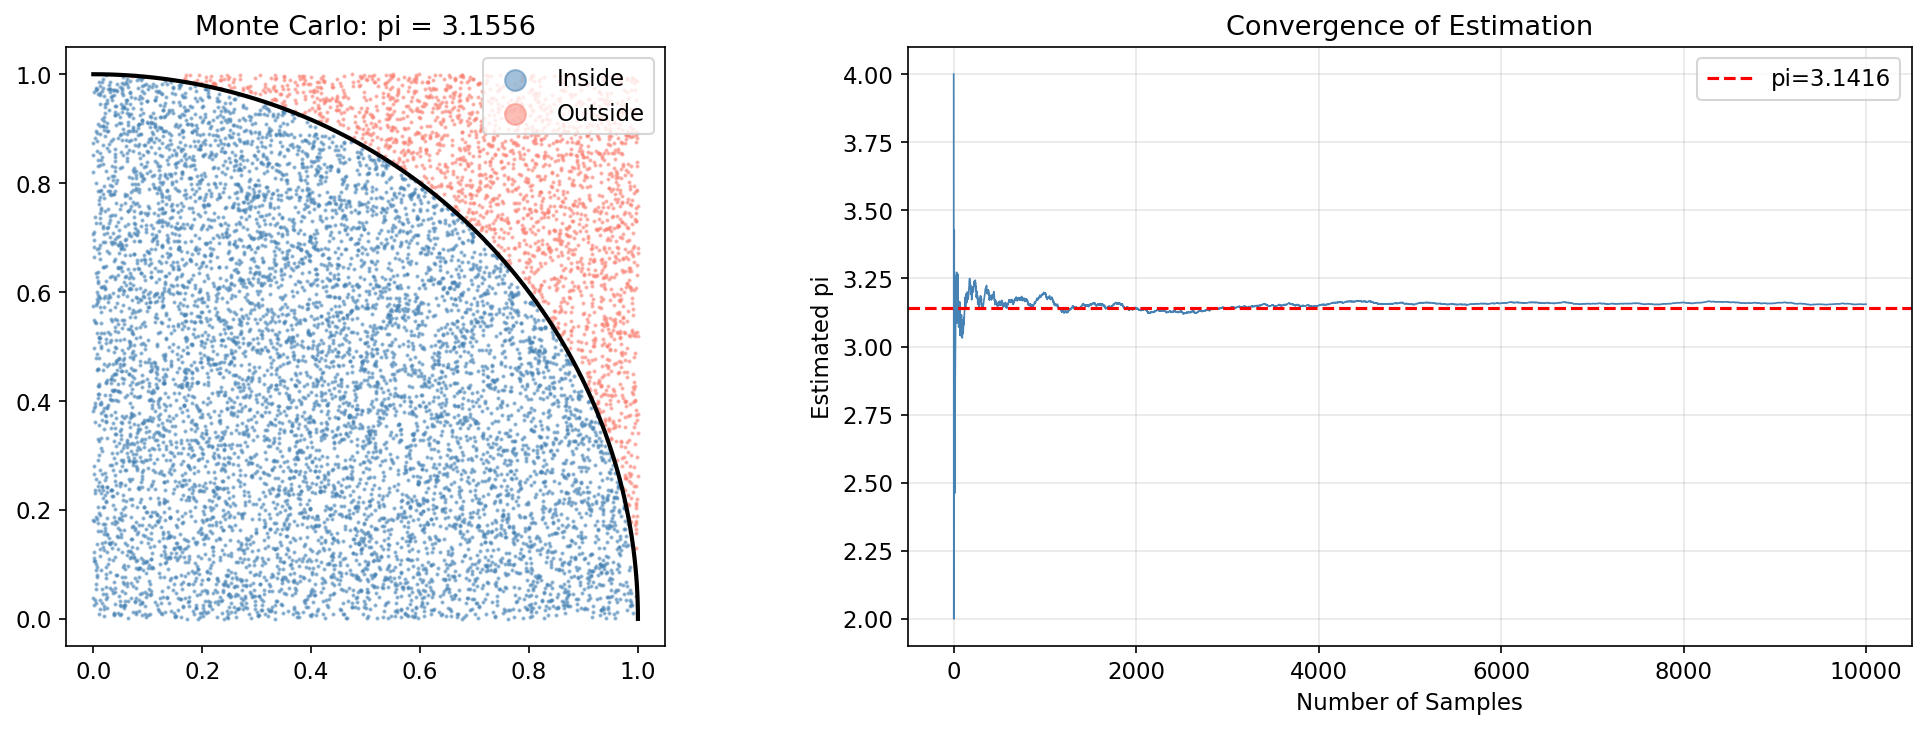

In [ ]:
np.random.seed(42)

n_points = 10000
x = np.random.uniform(0, 1, n_points)
y = np.random.uniform(0, 1, n_points)
inside = x**2 + y**2 <= 1

n_range = np.arange(1, n_points + 1)
pi_estimates = np.cumsum(inside) / n_range * 4

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: 点のプロット
axes[0].scatter(x[inside], y[inside], s=1, alpha=0.5, c='steelblue', label='Inside')
axes[0].scatter(x[~inside], y[~inside], s=1, alpha=0.5, c='salmon', label='Outside')
theta = np.linspace(0, np.pi/2, 100)
axes[0].plot(np.cos(theta), np.sin(theta), 'k-', linewidth=2)
axes[0].set_aspect('equal')
axes[0].set_title(f'Monte Carlo: pi = {pi_estimates[-1]:.4f}', fontsize=13)
axes[0].legend(markerscale=10)

# 右: 収束
axes[1].plot(n_range, pi_estimates, linewidth=0.8, color='steelblue')
axes[1].axhline(y=np.pi, color='red', linestyle='--', linewidth=1.5, label=f'pi={np.pi:.4f}')
axes[1].set_xlabel('Number of Samples')
axes[1].set_ylabel('Estimated pi')
axes[1].set_title('Convergence of Estimation', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. ブラウン運動と幾何ブラウン運動

**GBMの確率微分方程式**: $dS = \mu S \, dt + \sigma S \, dW$

**GBMの解**: $S(T) = S(t) \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)(T-t) + \sigma\sqrt{T-t} \cdot Z\right]$

### 図2・図3: ブラウン運動 vs 幾何ブラウン運動

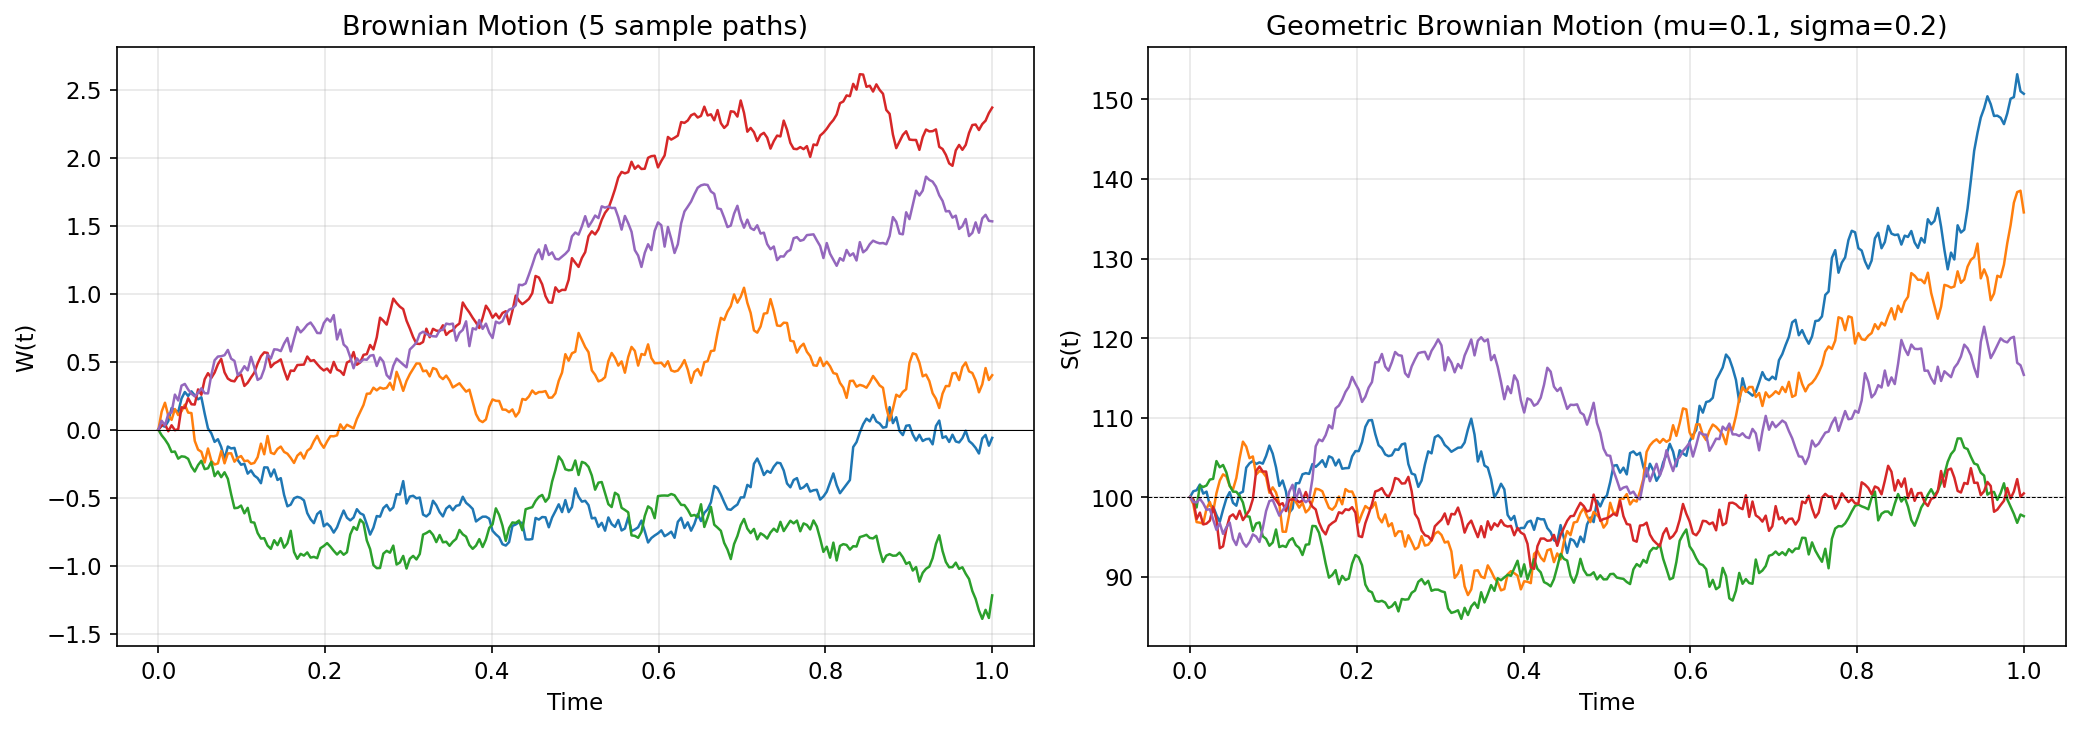

In [ ]:
np.random.seed(42)
T = 1.0
n_steps = 252
dt = T / n_steps
n_paths = 5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
t = np.linspace(0, T, n_steps + 1)

# ブラウン運動
for i in range(n_paths):
    Z = np.random.standard_normal(n_steps)
    W = np.zeros(n_steps + 1)
    W[1:] = np.cumsum(np.sqrt(dt) * Z)
    axes[0].plot(t, W, linewidth=1.2)

axes[0].set_title('Brownian Motion (5 sample paths)', fontsize=13)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('W(t)')
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# 幾何ブラウン運動
S0 = 100
mu_gbm = 0.1
sigma_gbm = 0.2

for i in range(n_paths):
    Z = np.random.standard_normal(n_steps)
    S = np.zeros(n_steps + 1)
    S[0] = S0
    for j in range(n_steps):
        S[j+1] = S[j] * np.exp((mu_gbm - 0.5 * sigma_gbm**2) * dt + sigma_gbm * np.sqrt(dt) * Z[j])
    axes[1].plot(t, S, linewidth=1.2)

axes[1].set_title(f'Geometric Brownian Motion (mu={mu_gbm}, sigma={sigma_gbm})', fontsize=13)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('S(t)')
axes[1].axhline(y=S0, color='black', linewidth=0.5, linestyle='--')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. 株価のモンテカルロシミュレーション

### データ取得とパラメータ推定

In [ ]:
tickers = ['AAPL', 'MSFT', 'AMZN', 'JPM', 'JNJ']
data = yf.download(tickers, start='2000-01-01', end='2025-12-31')['Close']

log_returns = np.log(data / data.shift(1)).dropna()

# AAPL パラメータ推定
mu_aapl = log_returns['AAPL'].mean() * 252
sigma_aapl = log_returns['AAPL'].std() * np.sqrt(252)
S0_aapl = data['AAPL'].iloc[-1]

print(f"AAPL Parameters:")
print(f"  Current Price: ${S0_aapl:.2f}")
print(f"  Annual Drift (mu): {mu_aapl:.4f}")
print(f"  Annual Volatility (sigma): {sigma_aapl:.4f}")

/tmp/ipykernel_12437/1602381917.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2000-01-01', end='2025-12-31')['Close']
[*********************100%***********************]  5 of 5 completed

AAPL Parameters:
  Current Price: $272.82
  Annual Drift (mu): 0.2230
  Annual Volatility (sigma): 0.3981


### 株価パスの生成（10,000本）

In [ ]:
np.random.seed(42)
n_simulations = 10000
n_days = 252
dt = 1 / 252

# ベクトル化シミュレーション
Z = np.random.standard_normal((n_days, n_simulations))
daily_returns = np.exp((mu_aapl - 0.5 * sigma_aapl**2) * dt + sigma_aapl * np.sqrt(dt) * Z)

S = np.zeros((n_days + 1, n_simulations))
S[0] = S0_aapl
for i in range(n_days):
    S[i+1] = S[i] * daily_returns[i]

print(f"Simulated {n_simulations} paths, {n_days} days each")
print(f"Final price statistics:")
print(f"  Mean: ${S[-1].mean():.2f}")
print(f"  Median: ${np.median(S[-1]):.2f}")
print(f"  Std: ${S[-1].std():.2f}")
print(f"  5th percentile: ${np.percentile(S[-1], 5):.2f}")
print(f"  95th percentile: ${np.percentile(S[-1], 95):.2f}")

Simulated 10000 paths, 252 days each
Final price statistics:
  Mean: $339.80
  Median: $314.61
  Std: $139.55
  5th percentile: $163.68
  95th percentile: $602.38


### 図4: AAPLモンテカルロシミュレーション（メインビジュアル）

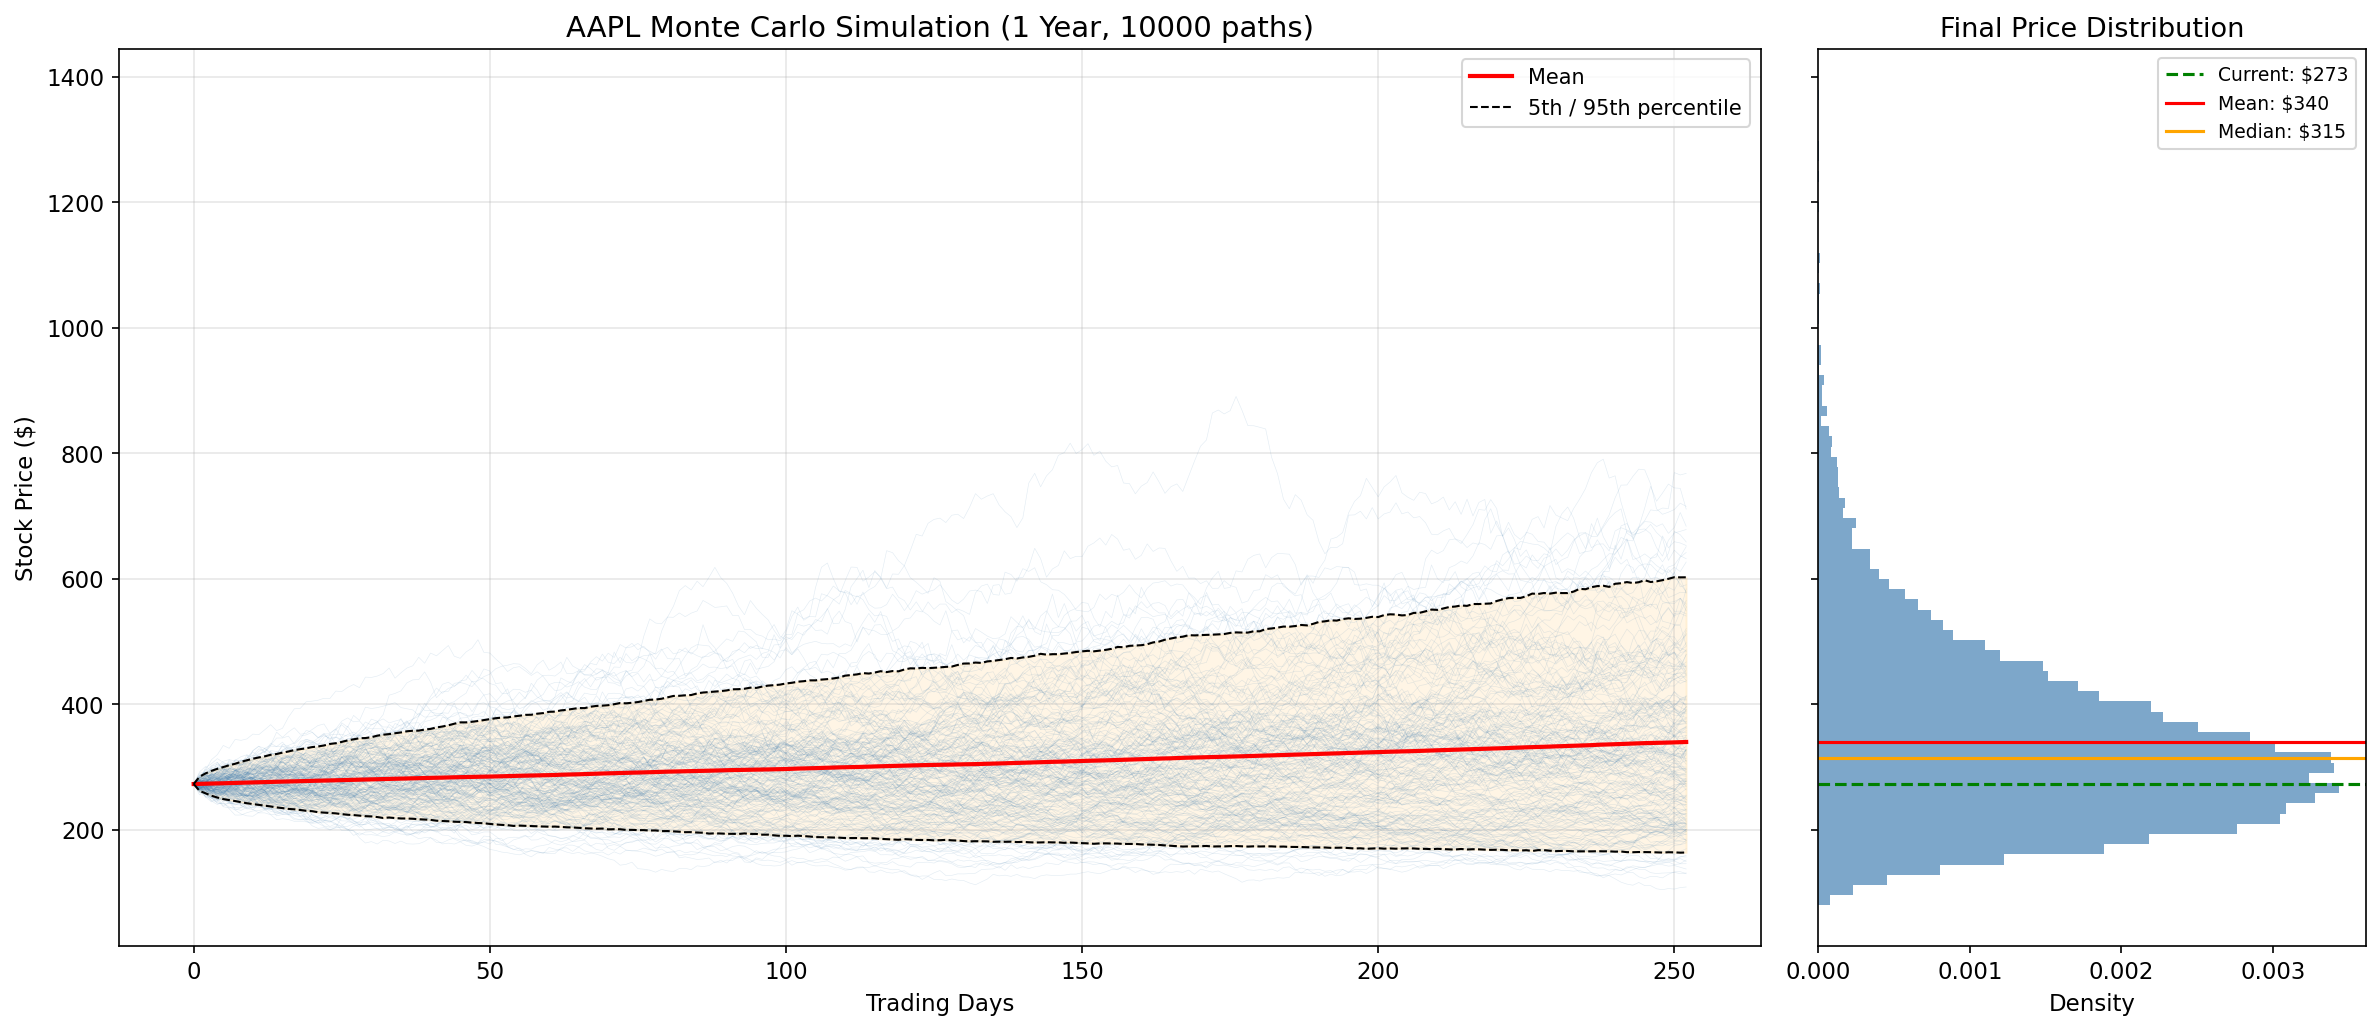

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                          gridspec_kw={'width_ratios': [3, 1]}, sharey=True)

t_axis = np.arange(n_days + 1)

# 左: パス
for i in range(200):
    axes[0].plot(t_axis, S[:, i], linewidth=0.3, alpha=0.15, color='steelblue')

p5 = np.percentile(S, 5, axis=1)
p95 = np.percentile(S, 95, axis=1)
mean_path = S.mean(axis=1)

axes[0].plot(t_axis, mean_path, 'r-', linewidth=2, label='Mean')
axes[0].plot(t_axis, p5, 'k--', linewidth=1, label='5th / 95th percentile')
axes[0].plot(t_axis, p95, 'k--', linewidth=1)
axes[0].fill_between(t_axis, p5, p95, alpha=0.1, color='orange')

axes[0].set_title(f'AAPL Monte Carlo Simulation (1 Year, {n_simulations} paths)', fontsize=14)
axes[0].set_xlabel('Trading Days')
axes[0].set_ylabel('Stock Price ($)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 右: 最終株価分布
axes[1].hist(S[-1], bins=80, orientation='horizontal', density=True,
             alpha=0.7, color='steelblue', edgecolor='none')
axes[1].axhline(y=S0_aapl, color='green', linestyle='--', linewidth=1.5, label=f'Current: ${S0_aapl:.0f}')
axes[1].axhline(y=np.mean(S[-1]), color='red', linestyle='-', linewidth=1.5, label=f'Mean: ${np.mean(S[-1]):.0f}')
axes[1].axhline(y=np.median(S[-1]), color='orange', linestyle='-', linewidth=1.5, label=f'Median: ${np.median(S[-1]):.0f}')
axes[1].set_xlabel('Density')
axes[1].set_title('Final Price Distribution', fontsize=13)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. VaRとCVaR

**VaR**: $\text{VaR}_{\alpha} = -Q_{\alpha}(R)$

**CVaR**: $\text{CVaR}_{\alpha} = -E[R \mid R \leq Q_{\alpha}(R)]$

In [ ]:
final_returns = S[-1] / S0_aapl - 1

confidence = 0.95
alpha = 1 - confidence
var_95 = -np.percentile(final_returns, alpha * 100)
cvar_95 = -np.mean(final_returns[final_returns <= -var_95])

print(f"=== Risk Metrics (1-Year, {confidence*100:.0f}% Confidence) ===")
print(f"VaR:  {var_95:.4f} ({var_95*100:.2f}%)")
print(f"CVaR: {cvar_95:.4f} ({cvar_95*100:.2f}%)")
print(f"")
print(f"If investing ${S0_aapl:.0f}:")
print(f"  VaR:  Max loss (95% CI) = ${S0_aapl * var_95:.2f}")
print(f"  CVaR: Expected loss beyond VaR = ${S0_aapl * cvar_95:.2f}")

=== Risk Metrics (1-Year, 95% Confidence) ===
VaR:  0.4001 (40.01%)
CVaR: 0.4874 (48.74%)

If investing $273:
  VaR:  Max loss (95% CI) = $109.14
  CVaR: Expected loss beyond VaR = $132.98


### 図5: リターン分布とVaR/CVaR

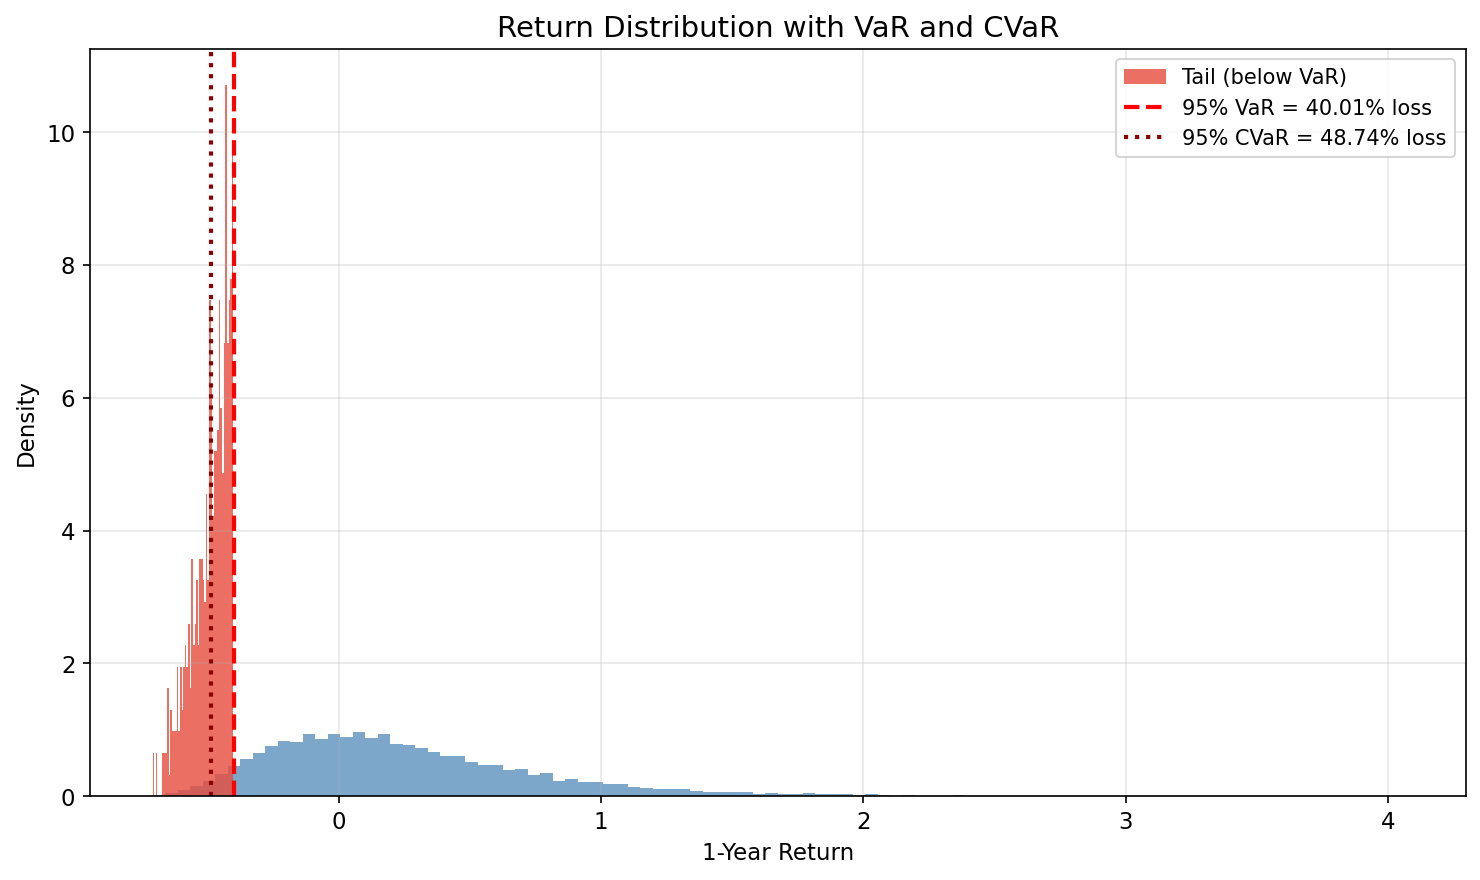

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(final_returns, bins=100, density=True, alpha=0.7, color='steelblue', edgecolor='none')

var_threshold = -var_95
returns_sorted = np.sort(final_returns)
tail_returns = returns_sorted[returns_sorted <= var_threshold]
ax.hist(tail_returns, bins=50, density=True, alpha=0.8, color='#e74c3c', edgecolor='none',
        label=f'Tail (below VaR)')

ax.axvline(x=var_threshold, color='red', linestyle='--', linewidth=2,
           label=f'95% VaR = {var_95*100:.2f}% loss')
ax.axvline(x=-cvar_95, color='darkred', linestyle=':', linewidth=2,
           label=f'95% CVaR = {cvar_95*100:.2f}% loss')

ax.set_title('Return Distribution with VaR and CVaR', fontsize=14)
ax.set_xlabel('1-Year Return')
ax.set_ylabel('Density')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. ポートフォリオへの応用

**コレスキー分解**: $\Sigma = LL^T$, $\mathbf{Z}_{\text{corr}} = L \cdot \mathbf{Z}_{\text{ind}}$

### パラメータ推定とコレスキー分解

In [ ]:
mu_all = log_returns.mean().values * 252
sigma_all = log_returns.std().values * np.sqrt(252)
corr_matrix = log_returns.corr().values
S0_all = data.iloc[-1].values

L = np.linalg.cholesky(corr_matrix)

print("=== Parameters ===")
for i, t in enumerate(tickers):
    print(f"  {t}: mu={mu_all[i]:.4f}, sigma={sigma_all[i]:.4f}, S0=${S0_all[i]:.2f}")
print(f"\nCorrelation Matrix:")
print(log_returns.corr().round(3))

=== Parameters ===
  AAPL: mu=0.2230, sigma=0.3981, S0=$272.82
  MSFT: mu=0.1523, sigma=0.4832, S0=$232.53
  AMZN: mu=0.0840, sigma=0.1917, S0=$205.82
  JPM: mu=0.1019, sigma=0.3678, S0=$320.33
  JNJ: mu=0.1009, sigma=0.3000, S0=$486.37

Correlation Matrix:
Ticker   AAPL   AMZN    JNJ    JPM   MSFT
Ticker                                   
AAPL    1.000  0.368  0.212  0.351  0.467
AMZN    0.368  1.000  0.145  0.325  0.449
JNJ     0.212  0.145  1.000  0.321  0.308
JPM     0.351  0.325  0.321  1.000  0.443
MSFT    0.467  0.449  0.308  0.443  1.000


### 相関を考慮した多銘柄シミュレーション

In [ ]:
np.random.seed(42)
n_simulations = 10000
n_days = 252
n_assets = len(tickers)
dt = 1 / 252

weights = np.ones(n_assets) / n_assets
portfolio_values = np.zeros((n_days + 1, n_simulations))
portfolio_values[0] = 1.0

S_all = np.zeros((n_assets, n_days + 1, n_simulations))
for k in range(n_assets):
    S_all[k, 0] = S0_all[k]

for t_step in range(n_days):
    Z_ind = np.random.standard_normal((n_assets, n_simulations))
    Z_corr = L @ Z_ind

    for k in range(n_assets):
        S_all[k, t_step+1] = S_all[k, t_step] * np.exp(
            (mu_all[k] - 0.5 * sigma_all[k]**2) * dt + sigma_all[k] * np.sqrt(dt) * Z_corr[k]
        )

    daily_rets = np.zeros(n_simulations)
    for k in range(n_assets):
        daily_rets += weights[k] * (S_all[k, t_step+1] / S_all[k, t_step] - 1)
    portfolio_values[t_step+1] = portfolio_values[t_step] * (1 + daily_rets)

print(f"Portfolio Simulation Complete: {n_simulations} paths")
print(f"Final Portfolio Value Statistics:")
print(f"  Mean: {portfolio_values[-1].mean():.4f}")
print(f"  Median: {np.median(portfolio_values[-1]):.4f}")
print(f"  Std: {portfolio_values[-1].std():.4f}")

Portfolio Simulation Complete: 10000 paths
Final Portfolio Value Statistics:
  Mean: 1.1379
  Median: 1.1067
  Std: 0.2811


### 図6: ポートフォリオのモンテカルロシミュレーション

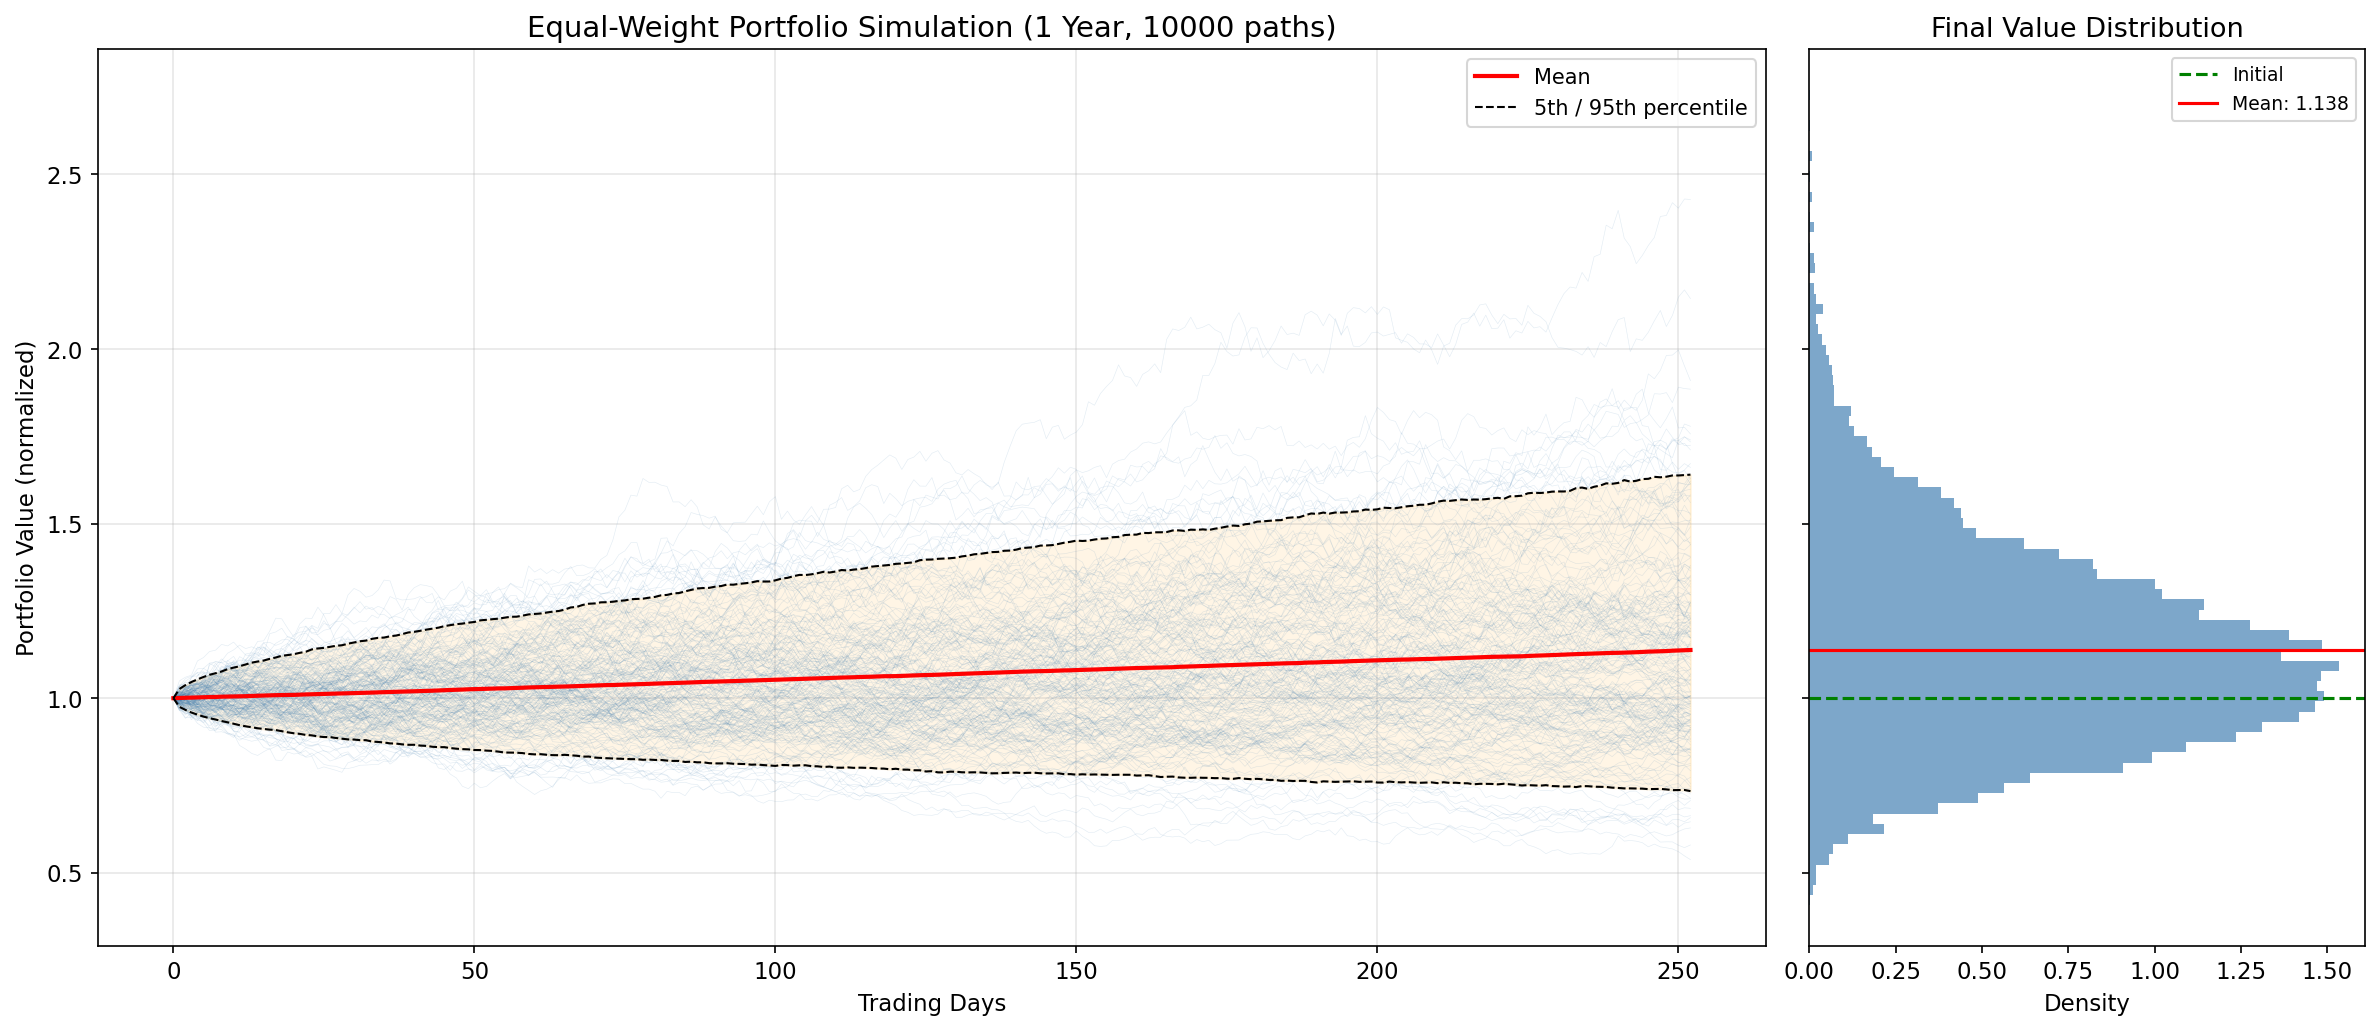


=== Portfolio Risk Metrics (95% Confidence) ===
VaR:  26.62%
CVaR: 33.55%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                          gridspec_kw={'width_ratios': [3, 1]}, sharey=True)

t_axis = np.arange(n_days + 1)

for i in range(200):
    axes[0].plot(t_axis, portfolio_values[:, i], linewidth=0.3, alpha=0.15, color='steelblue')

p5 = np.percentile(portfolio_values, 5, axis=1)
p95 = np.percentile(portfolio_values, 95, axis=1)
mean_path = portfolio_values.mean(axis=1)

axes[0].plot(t_axis, mean_path, 'r-', linewidth=2, label='Mean')
axes[0].plot(t_axis, p5, 'k--', linewidth=1, label='5th / 95th percentile')
axes[0].plot(t_axis, p95, 'k--', linewidth=1)
axes[0].fill_between(t_axis, p5, p95, alpha=0.1, color='orange')

axes[0].set_title(f'Equal-Weight Portfolio Simulation (1 Year, {n_simulations} paths)', fontsize=14)
axes[0].set_xlabel('Trading Days')
axes[0].set_ylabel('Portfolio Value (normalized)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].hist(portfolio_values[-1], bins=80, orientation='horizontal', density=True,
             alpha=0.7, color='steelblue', edgecolor='none')
axes[1].axhline(y=1.0, color='green', linestyle='--', linewidth=1.5, label='Initial')
axes[1].axhline(y=np.mean(portfolio_values[-1]), color='red', linestyle='-', linewidth=1.5,
                label=f'Mean: {np.mean(portfolio_values[-1]):.3f}')
axes[1].set_xlabel('Density')
axes[1].set_title('Final Value Distribution', fontsize=13)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ポートフォリオ VaR/CVaR
port_returns = portfolio_values[-1] / portfolio_values[0] - 1
port_var = -np.percentile(port_returns, 5)
port_cvar = -np.mean(port_returns[port_returns <= -port_var])
print(f"\n=== Portfolio Risk Metrics (95% Confidence) ===")
print(f"VaR:  {port_var*100:.2f}%")
print(f"CVaR: {port_cvar*100:.2f}%")